Advitiya Apurv 24EE10029  Afrin Munshi 24EE10030



In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random

In [144]:
class MultiLayerPerceptron:
    def __init__(self, n_in, n_hidden_list, n_out, eta, alpha, decay_freq):
        self.eta = eta
        self.alpha = alpha
        self.decay_freq = decay_freq
        self.layer_sizes = [n_in] + n_hidden_list + [n_out]


        self.weights = []
        for i in range(len(self.layer_sizes) - 1):

            self.weights.append(np.zeros((self.layer_sizes[i] + 1, self.layer_sizes[i+1])))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        activations = [x]
        curr_in = x
        for w in self.weights:

            curr_in_b = np.hstack([curr_in, np.ones((curr_in.shape[0], 1))])
            net = np.dot(curr_in_b, w)
            curr_in = self.sigmoid(net)
            activations.append(curr_in)
        return activations

    def train_epoch(self, train_data):
        np.random.shuffle(train_data)
        for row in train_data:
            x = row[:-1].reshape(1, -1)
            target = row[-1:].reshape(1, -1)
            acts = self.forward(x)
            deltas = [None] * len(self.weights)


            out = acts[-1]
            error_out = target - out
            deltas[-1] = out * (1 - out) * error_out


            for i in reversed(range(len(self.weights) - 1)):
                w_no_bias = self.weights[i+1][:-1, :]
                error_h = np.dot(deltas[i+1], w_no_bias.T)
                deltas[i] = acts[i+1] * (1 - acts[i+1]) * error_h

            for i in range(len(self.weights)):
                inp_b = np.hstack([acts[i], np.ones((acts[i].shape[0], 1))])
                self.weights[i] += self.eta * np.dot(inp_b.T, deltas[i])

    def evaluate(self, data):
        X, y = data[:, :-1], data[:, -1:]
        acts = self.forward(X)
        output = acts[-1]
        mse = np.mean((y - output)**2)
        preds = (output >= 0.5).astype(float)
        acc = np.mean(preds == y)
        return mse, acc, preds

In [145]:
def prepare_data(data, train_seg, val_seg):

    np.random.shuffle(data)

    n = len(data)
    tr_idx = int(n * train_seg / 100)
    val_idx = tr_idx + int(n * val_seg / 100)

    return data[:tr_idx], data[tr_idx:val_idx], data[val_idx:]




In [146]:
cols = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","target"]

In [147]:
df = pd.read_csv("processed.cleveland.data", header=None,na_values="?")
df=df.fillna(0.0)
cland = df.to_numpy()
df = pd.read_csv("processed.hungarian.data", header=None,na_values="?")
df=df.fillna(0.0)
hung=df.to_numpy()
df = pd.read_csv("processed.switzerland.data", header=None,na_values="?")
df=df.fillna(0.0)
swit=df.to_numpy()
df = pd.read_csv("processed.va.data", header=None,na_values="?")
df=df.fillna(0.0)
va=df.to_numpy()
print(np.shape(cland))


(303, 14)


In [148]:
nin=14
nout=1
hidl=1
nhid=[0]*hidl
rate=0.1
alpha=1
freq=1000
iter=100
maxErr=10
overfit=20

XOR of 2 bit

In [149]:

xor_data = np.array([
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])


n_in = 2
n_out = 1
eta = 0.1
alpha = 1.0
decay_freq = float('inf')
maxIter = 200


w = [0.0, 0.0, 0.0]
v = [0.0, 0.0, 0.0]



In [150]:
errors = []
weights_history = [[], [], []]

for i in range(maxIter):
    total_error = 0

    for row in xor_data:
        x = row[:2]
        target = row[2]


        z = exp(w, x)
        pred = sigmoid(z)


        total_error += (target - pred)**2


        delta = (target - pred) * pred * (1 - pred)


        for j in range(len(x)):
            grad = delta * x[j]
            v[j] = alpha * v[j] + eta * grad
            w[j] += v[j]


        v[2] = alpha * v[2] + eta * delta
        w[2] += v[2]

    errors.append(total_error)
    weights_history[0].append(w[0])
    weights_history[1].append(w[1])
    weights_history[2].append(w[2])



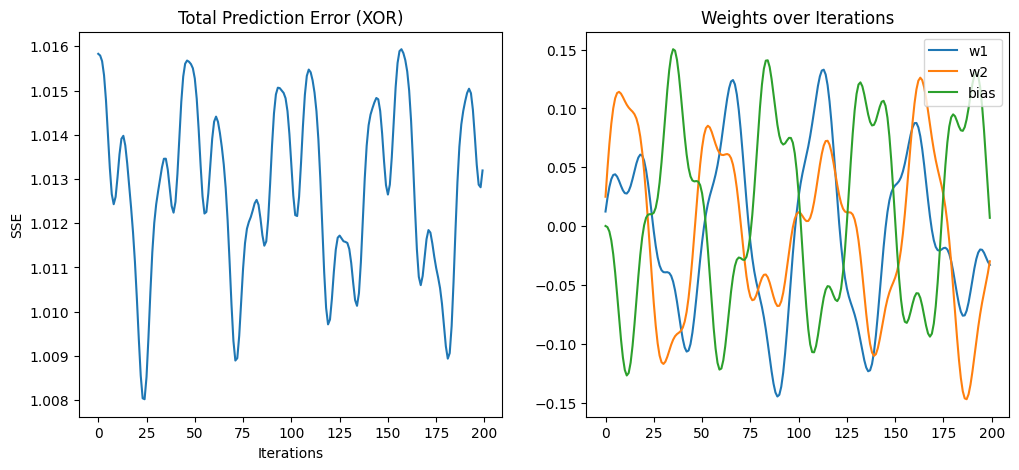

Final XOR Equation: y = sigmoid(-0.0329*x1 + -0.0298*x2 + 0.0071)


In [151]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(errors)
plt.title("Total Prediction Error (XOR)")
plt.xlabel("Iterations")
plt.ylabel("SSE")

plt.subplot(1, 2, 2)
plt.plot(weights_history[0], label="w1")
plt.plot(weights_history[1], label="w2")
plt.plot(weights_history[2], label="bias")
plt.title("Weights over Iterations")
plt.legend()
plt.show()

print(f"Final XOR Equation: y = sigmoid({w[0]:.4f}*x1 + {w[1]:.4f}*x2 + {w[2]:.4f})")

For 2 Bit XNOR

In [152]:

xnor_data = np.array([[0,0,1], [0,1,0], [1,0,0], [1,1,1]])


err_xnor, w_xnor_history = train_xor_with_order(xnor_data, shuffle=False)
final_w_xnor = w_xnor_history[-1]



print(f"XNOR Final Weights (w1, w2, bias): {[round(x, 4) for x in final_w_xnor]}")


print(f"XNOR Equation: y = sigmoid({final_w_xnor[0]:.2f}x1 + {final_w_xnor[1]:.2f}x2 + {final_w_xnor[2]:.2f})")

XNOR Final Weights (w1, w2, bias): [np.float64(0.0113), np.float64(0.0054), np.float64(-0.0002)]
XNOR Equation: y = sigmoid(0.01x1 + 0.01x2 + -0.00)


In [153]:
def calculate_accuracy(data, weights):
    correct = 0
    print("\nPredictions vs Actual:")
    for row in data:
        x = row[:2]
        target = row[2]
        pred = sigmoid(exp(weights, x))
        binary_pred = 1 if pred >= 0.5 else 0
        if binary_pred == target:
            correct += 1
        print(f"Input: {x}, Target: {target}, Pred: {pred:.4f} -> Result: {binary_pred}")

    return (correct / len(data)) * 100

acc_xor = calculate_accuracy(xor_data, final_w_xor)
print(f"\nFinal XOR Accuracy: {acc_xor}%")

acc_xnor = calculate_accuracy(xnor_data, final_w_xnor)
print(f"Final XNOR Accuracy: {acc_xnor}%")


Predictions vs Actual:
Input: [0 0], Target: 0, Pred: 0.5001 -> Result: 1
Input: [0 1], Target: 1, Pred: 0.4987 -> Result: 0
Input: [1 0], Target: 1, Pred: 0.4972 -> Result: 0
Input: [1 1], Target: 0, Pred: 0.4959 -> Result: 0

Final XOR Accuracy: 25.0%

Predictions vs Actual:
Input: [0 0], Target: 1, Pred: 0.4999 -> Result: 0
Input: [0 1], Target: 0, Pred: 0.5013 -> Result: 1
Input: [1 0], Target: 0, Pred: 0.5028 -> Result: 1
Input: [1 1], Target: 1, Pred: 0.5041 -> Result: 1
Final XNOR Accuracy: 25.0%


Important Observations
1. Fails to converge using single layer perceptron
2. XNOR has close to the negative of weights of XOR
3. The error converges at around 0.6
4. Changing the sequence decreases the error to close to 0.3 after several iterations, show much better results than the XOR sequence generally used
5. Multilayering is needed to make XOR work

PART-2, Working of ANN for Cleveland and Others

In [154]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(out):
    return out * (1 - out)

def get_confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

In [155]:
data_binary = cland.copy()
data_binary[:, -1] = (data_binary[:, -1] > 0).astype(float)

np.random.seed(42)
np.random.shuffle(data_binary)
n = len(data_binary)
train_end = int(n * 0.8)
val_end = train_end + int(n * 0.1)

train_set = data_binary[:train_end]
val_set = data_binary[train_end:val_end]
test_set = data_binary[val_end:]

In [156]:
n_in = 13
n_hidden = 5
n_out = 1
eta = 0.1
alpha = 1.0


w_hid = np.zeros((n_in + 1, n_hidden))
w_out = np.zeros((n_hidden + 1, n_out))


history = {'train_err': [], 'val_err': [], 'test_err': []}
cms = {}


for epoch in range(1, 101):

    for row in train_set:
        x = row[:-1].reshape(1, -1)
        target = row[-1]


        x_with_bias = np.hstack([x, [[1.0]]])
        hid_act = sigmoid(np.dot(x_with_bias, w_hid))


        hid_with_bias = np.hstack([hid_act, [[1.0]]])
        output = sigmoid(np.dot(hid_with_bias, w_out))


        error_out = target - output
        delta_out = error_out * sigmoid_derivative(output)

        error_hid = np.dot(delta_out, w_out[:-1, :].T)
        delta_hid = error_hid * sigmoid_derivative(hid_act)


        w_out += eta * np.dot(hid_with_bias.T, delta_out)
        w_hid += eta * np.dot(x_with_bias.T, delta_hid)


    def evaluate(dataset):
        X = dataset[:, :-1]
        Y = dataset[:, -1:]

        X_b = np.hstack([X, np.ones((len(X), 1))])
        H = sigmoid(np.dot(X_b, w_hid))
        H_b = np.hstack([H, np.ones((len(H), 1))])
        P = sigmoid(np.dot(H_b, w_out))
        mse = np.mean((Y - P)**2)
        preds = (P >= 0.5).astype(float)
        acc = np.mean(preds == Y)
        return mse, acc, preds

    tr_mse, tr_acc, _ = evaluate(train_set)
    val_mse, val_acc, _ = evaluate(val_set)
    ts_mse, ts_acc, ts_preds = evaluate(test_set)

    history['train_err'].append(tr_mse)
    history['val_err'].append(val_mse)
    history['test_err'].append(ts_mse)


    if epoch % 20 == 0:
        cms[epoch] = get_confusion_matrix(test_set[:, -1:], ts_preds)
        print(f"Epoch {epoch} Confusion Matrix:\n", cms[epoch])


    if (tr_acc - val_acc) * 100 > 30:
        print(f"Terminated at epoch {epoch}: Overfitting limit exceeded.")
        break


    test_misclass_rate = (1 - ts_acc) * 100
    if test_misclass_rate <= 5:
        print(f"Terminated at epoch {epoch}: Error tolerance met.")
        break




Epoch 20 Confusion Matrix:
 [[ 0 17]
 [ 0 14]]
Epoch 40 Confusion Matrix:
 [[ 0 17]
 [ 0 14]]
Epoch 60 Confusion Matrix:
 [[ 0 17]
 [ 0 14]]
Epoch 80 Confusion Matrix:
 [[17  0]
 [14  0]]
Epoch 100 Confusion Matrix:
 [[17  0]
 [14  0]]


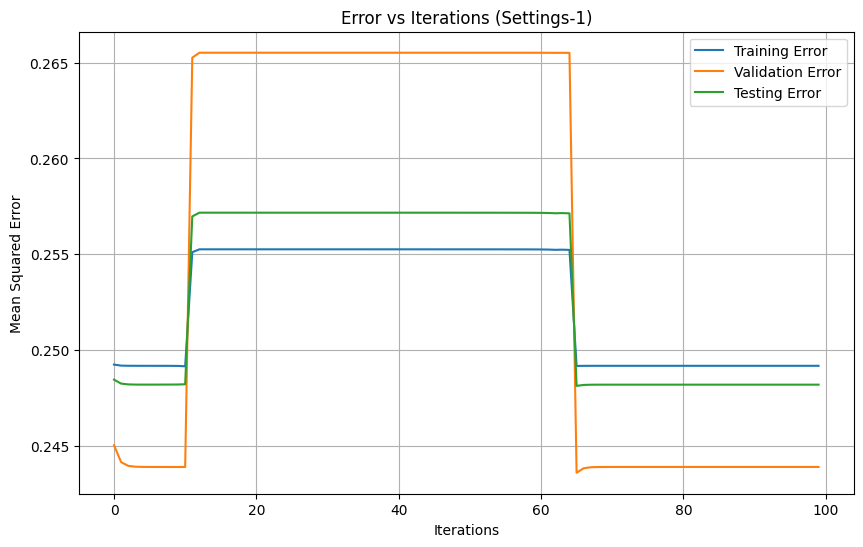

In [157]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_err'], label='Training Error')
plt.plot(history['val_err'], label='Validation Error')
plt.plot(history['test_err'], label='Testing Error')
plt.title('Error vs Iterations (Settings-1)')
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

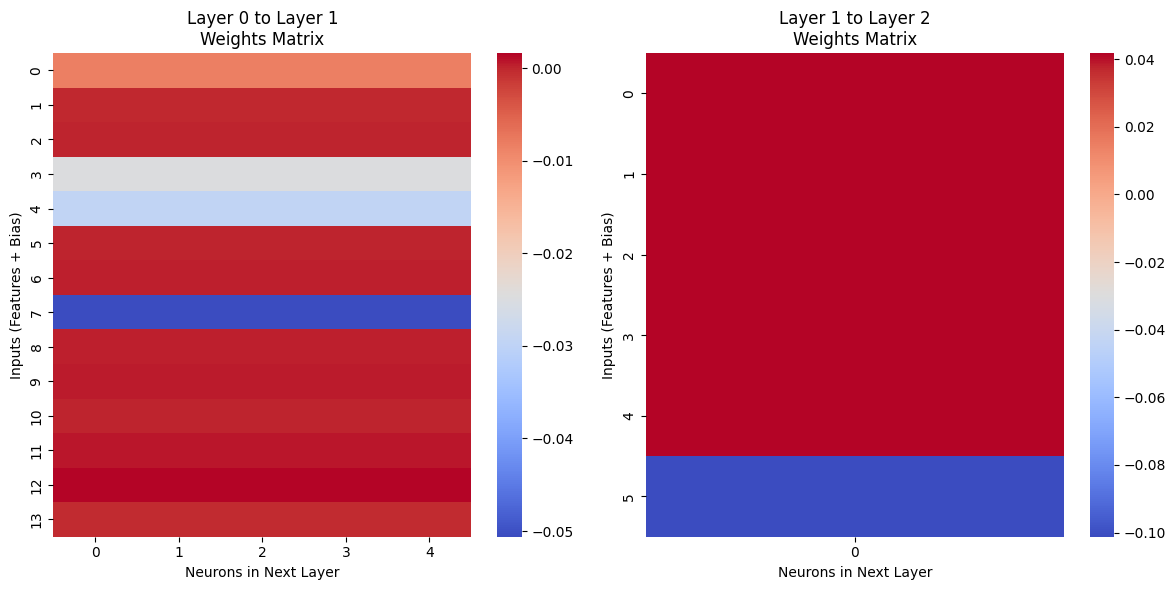

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weights(weights_list):
    """
    weights_list: A list containing weight matrices for each layer.
    e.g., [w_hidden, w_output]
    """
    num_layers = len(weights_list)

    fig, axes = plt.subplots(1, num_layers, figsize=(12, 6))

    if num_layers == 1:
        axes = [axes]

    for i, w in enumerate(weights_list):

        w_array = np.array(w)


        sns.heatmap(w_array, ax=axes[i], cmap='coolwarm', annot=False, cbar=True)

        axes[i].set_title(f'Layer {i} to Layer {i+1}\nWeights Matrix')
        axes[i].set_xlabel('Neurons in Next Layer')
        axes[i].set_ylabel('Inputs (Features + Bias)')

    plt.tight_layout()
    plt.show()


plot_weights([w_hid, w_out])

In [159]:
def preprocess_binary(data):
    d = data.copy()
    d[:, -1] = (d[:, -1] > 0).astype(float)
    return d

def get_cm(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

In [160]:
def run_experiment(train_name, datasets_dict, config):
    print(f"\n{'='*40}\nTRAINING ON: {train_name}\n{'='*40}")
    data = datasets_dict[train_name]


    tr, val, ts = prepare_data(data, config['tr_seg'], config['val_seg'])
    model = MultiLayerPerceptron(13, config['n_hidden'], 1, config['eta'], config['alpha'], config['decay_freq'])

    history = {'tr_err': [], 'val_err': [], 'ts_err': []}

    for epoch in range(1, config['maxIter'] + 1):
        model.train_epoch(tr)
        if epoch % config['decay_freq'] == 0: model.eta *= model.alpha


        tr_mse, tr_acc, _ = model.evaluate(tr)
        val_mse, val_acc, _ = model.evaluate(val)
        ts_mse, ts_acc, ts_preds = model.evaluate(ts)

        history['tr_err'].append(tr_mse)
        history['val_err'].append(val_mse)
        history['ts_err'].append(ts_mse)


        if epoch % 20 == 0:
            print(f"Epoch {epoch} Test Confusion Matrix:\n{get_cm(ts[:, -1:], ts_preds)}")


        if (1 - ts_acc)*100 <= config['maxErr']: break
        if (tr_acc - val_acc)*100 > config['percentOverfit']: break


    plt.figure(figsize=(8, 4))
    plt.plot(history['tr_err'], label='Train MSE')
    plt.plot(history['val_err'], label='Val MSE')
    plt.plot(history['ts_err'], label='Test MSE')
    plt.title(f"Errors - {train_name}"); plt.legend(); plt.show()


    for i, w in enumerate(model.weights):
        plt.figure(figsize=(6, 4))
        sns.heatmap(w, cmap='viridis')
        plt.title(f"Weight Matrix Layer {i} ({train_name})"); plt.show()


    print(f"Cross-dataset results for {train_name} model:")
    for name, d_set in datasets_dict.items():
        if name != train_name:
            _, _, p = model.evaluate(d_set)
            print(f"Tested on {name} CM:\n{get_cm(d_set[:, -1:], p)}")

    return model





TRAINING ON: Cleveland
Epoch 20 Test Confusion Matrix:
[[18  0]
 [13  0]]
Epoch 40 Test Confusion Matrix:
[[18  0]
 [13  0]]
Epoch 60 Test Confusion Matrix:
[[18  0]
 [13  0]]
Epoch 80 Test Confusion Matrix:
[[18  0]
 [13  0]]
Epoch 100 Test Confusion Matrix:
[[18  0]
 [13  0]]


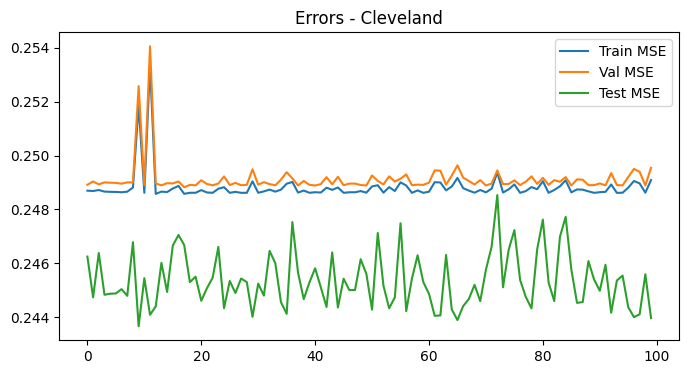

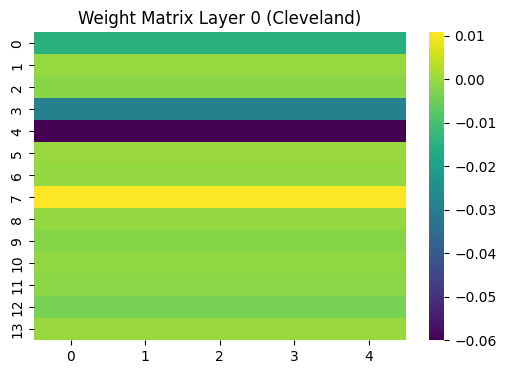

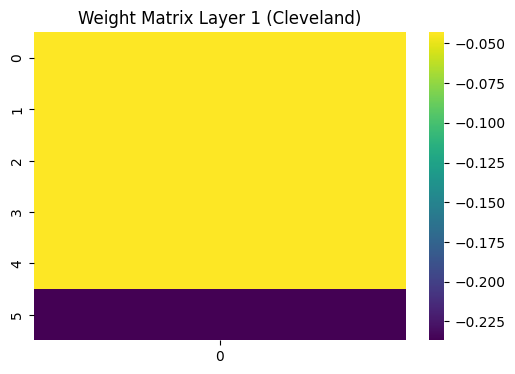

Cross-dataset results for Cleveland model:
Tested on Hungarian CM:
[[188   0]
 [106   0]]
Tested on Switzerland CM:
[[  8   0]
 [115   0]]
Tested on VA CM:
[[ 51   0]
 [149   0]]

TRAINING ON: Hungarian
Epoch 20 Test Confusion Matrix:
[[21  0]
 [ 9  0]]
Epoch 40 Test Confusion Matrix:
[[21  0]
 [ 9  0]]
Epoch 60 Test Confusion Matrix:
[[21  0]
 [ 9  0]]
Epoch 80 Test Confusion Matrix:
[[21  0]
 [ 9  0]]
Epoch 100 Test Confusion Matrix:
[[21  0]
 [ 9  0]]


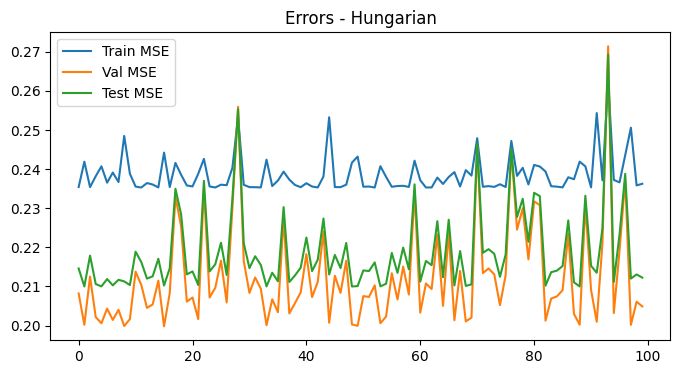

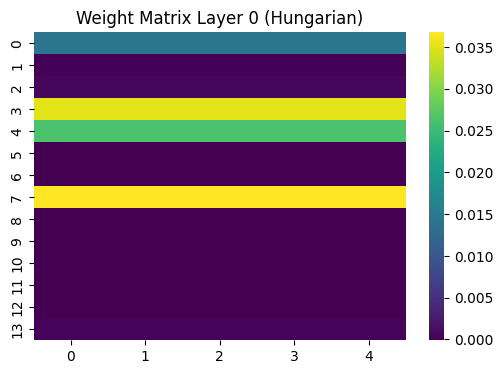

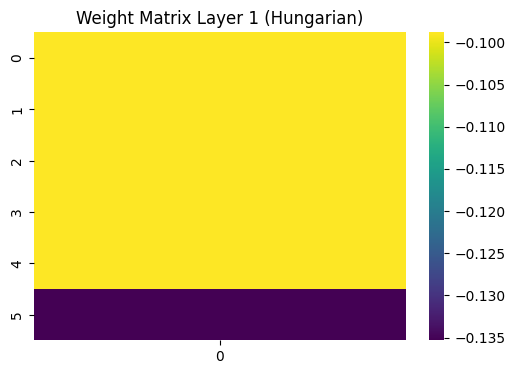

Cross-dataset results for Hungarian model:
Tested on Cleveland CM:
[[164   0]
 [139   0]]
Tested on Switzerland CM:
[[  8   0]
 [115   0]]
Tested on VA CM:
[[ 51   0]
 [149   0]]

TRAINING ON: Switzerland


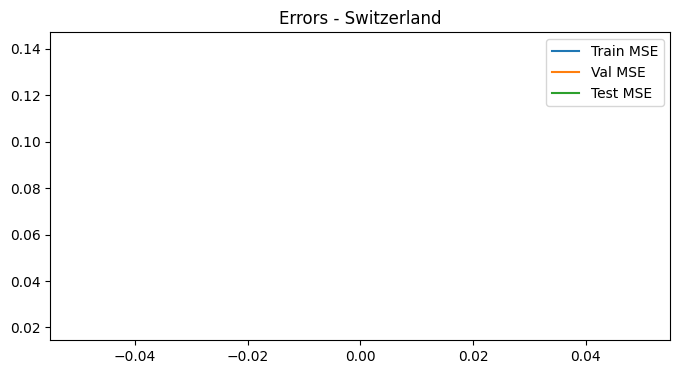

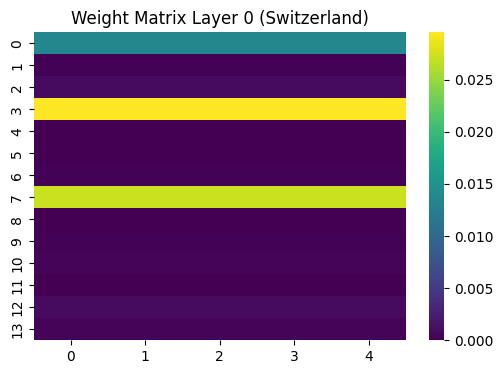

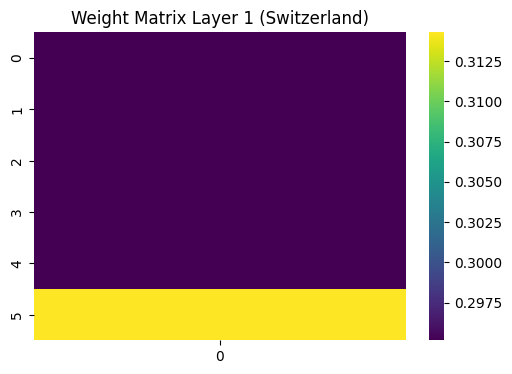

Cross-dataset results for Switzerland model:
Tested on Cleveland CM:
[[  0 164]
 [  0 139]]
Tested on Hungarian CM:
[[  0 188]
 [  0 106]]
Tested on VA CM:
[[  0  51]
 [  0 149]]

TRAINING ON: VA
Epoch 20 Test Confusion Matrix:
[[ 0  5]
 [ 0 15]]
Epoch 40 Test Confusion Matrix:
[[ 0  5]
 [ 0 15]]
Epoch 60 Test Confusion Matrix:
[[ 0  5]
 [ 0 15]]
Epoch 80 Test Confusion Matrix:
[[ 0  5]
 [ 0 15]]
Epoch 100 Test Confusion Matrix:
[[ 0  5]
 [ 0 15]]


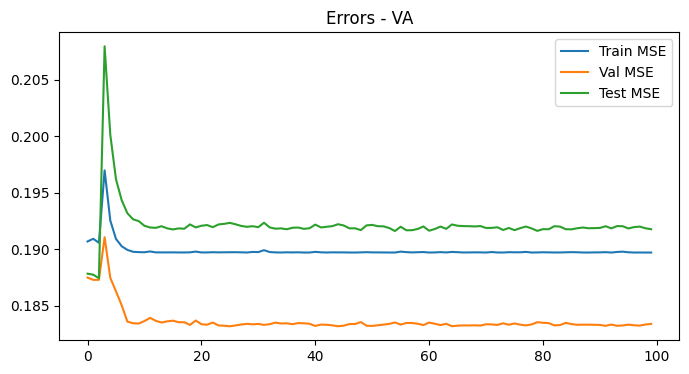

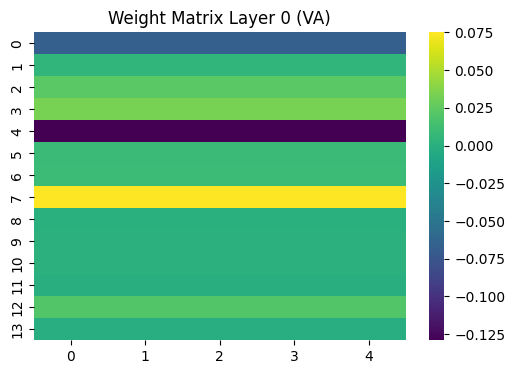

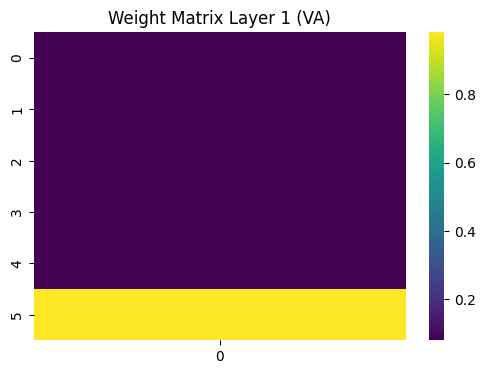

Cross-dataset results for VA model:
Tested on Cleveland CM:
[[  0 164]
 [  0 139]]
Tested on Hungarian CM:
[[  0 188]
 [  0 106]]
Tested on Switzerland CM:
[[  0   8]
 [  0 115]]

TRAINING ON: Combined
Epoch 20 Test Confusion Matrix:
[[ 0 42]
 [ 0 50]]
Epoch 40 Test Confusion Matrix:
[[39  3]
 [29 21]]
Epoch 60 Test Confusion Matrix:
[[39  3]
 [29 21]]
Epoch 80 Test Confusion Matrix:
[[39  3]
 [29 21]]
Epoch 100 Test Confusion Matrix:
[[39  3]
 [29 21]]


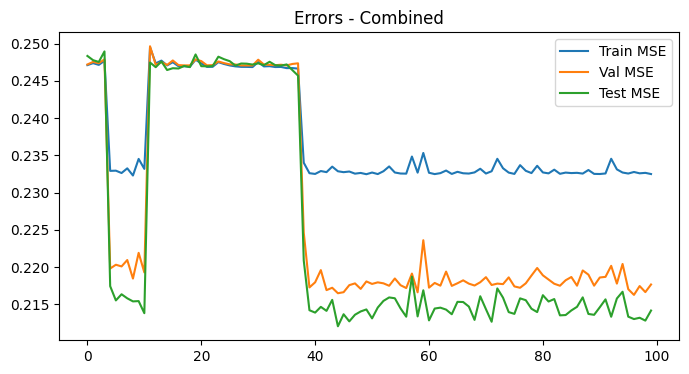

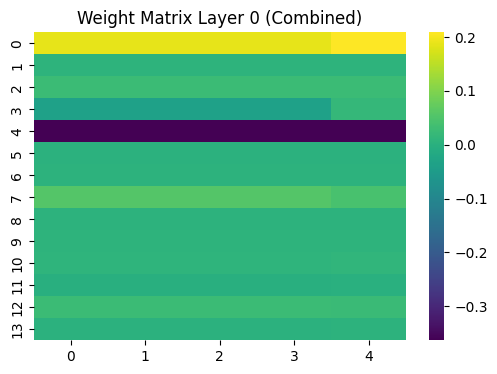

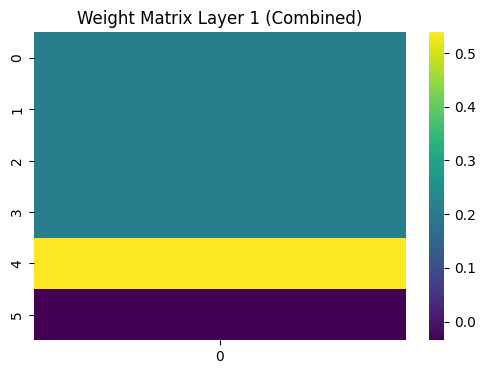

Cross-dataset results for Combined model:


In [161]:
data_dict = {
    "Cleveland": preprocess_binary(cland),
    "Hungarian": preprocess_binary(hung),
    "Switzerland": preprocess_binary(swit),
    "VA": preprocess_binary(va)
}

config_s1 = {
    'n_hidden': [5], 'eta': 0.1, 'alpha': 1.0, 'decay_freq': 9999,
    'maxIter': 100, 'maxErr': 5, 'percentOverfit': 30, 'tr_seg': 80, 'val_seg': 10
}


cleveland_model = run_experiment("Cleveland", data_dict, config_s1)


for name in ["Hungarian", "Switzerland", "VA"]:
    run_experiment(name, data_dict, config_s1)


combined_data = np.vstack(list(data_dict.values()))
run_experiment("Combined", {"Combined": combined_data}, config_s1)

In [162]:

def get_binary_data(data):
    d = data.copy()
    d[:, -1] = (d[:, -1] > 0).astype(float)
    return d


def get_multiclass_data(data):

    return data.copy()

In [163]:

base_config = {
    'n_in': 13, 'n_out': 1, 'n_hidden': [5], 'eta': 0.1,
    'alpha': 1.0, 'decay_freq': 9999, 'maxIter': 100,
    'maxErr': 5, 'percentOverfit': 30, 'tr_seg': 80, 'val_seg': 10
}


config_s2 = base_config.copy()
config_s2['n_hidden'] = [5, 3]


config_s3 = base_config.copy()
config_s3['tr_seg'] = 60
config_s3['val_seg'] = 20

config_s4 = base_config.copy()
config_s4['alpha'] = 0.9
config_s4['decay_freq'] = 20


config_s5 = config_s2.copy()
config_s5['n_out'] = 1


Running Setting-2 (Complexity) on Cleveland Dataset...

TRAINING ON: Cleveland_Setting-2 (Complexity)
Epoch 20 Test Confusion Matrix:
[[15  0]
 [16  0]]
Epoch 40 Test Confusion Matrix:
[[15  0]
 [16  0]]
Epoch 60 Test Confusion Matrix:
[[15  0]
 [16  0]]
Epoch 80 Test Confusion Matrix:
[[15  0]
 [16  0]]
Epoch 100 Test Confusion Matrix:
[[15  0]
 [16  0]]


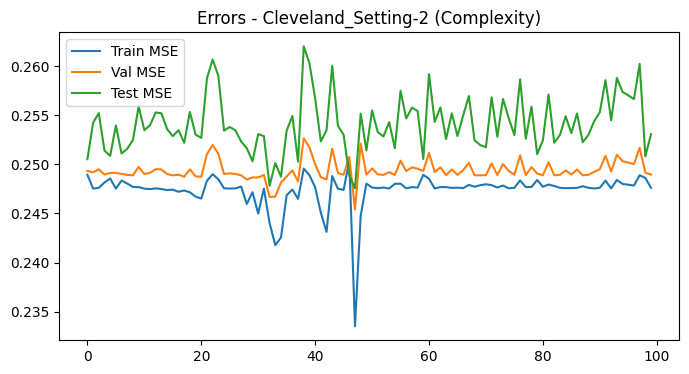

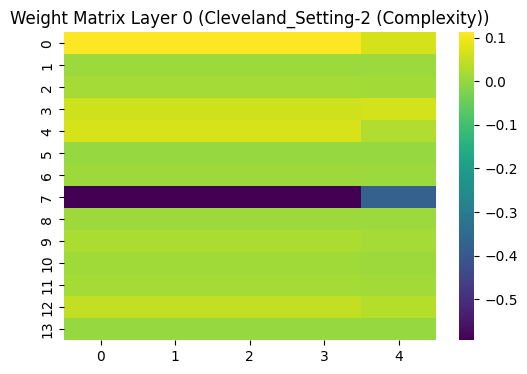

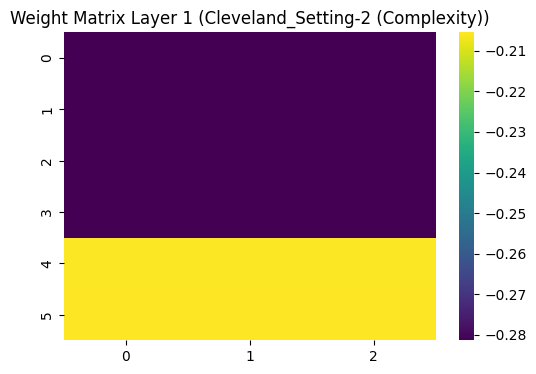

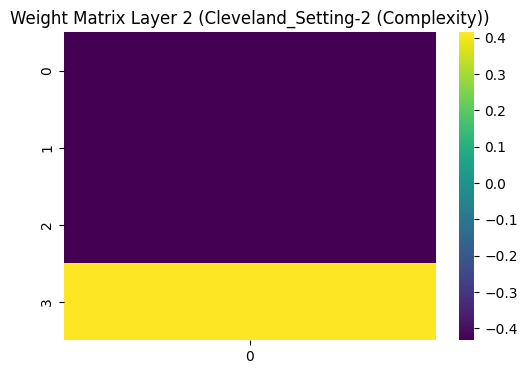

Cross-dataset results for Cleveland_Setting-2 (Complexity) model:

Running Setting-3 (Generalization) on Cleveland Dataset...

TRAINING ON: Cleveland_Setting-3 (Generalization)
Epoch 20 Test Confusion Matrix:
[[33  0]
 [29  0]]
Epoch 40 Test Confusion Matrix:
[[33  0]
 [29  0]]
Epoch 60 Test Confusion Matrix:
[[33  0]
 [29  0]]
Epoch 80 Test Confusion Matrix:
[[33  0]
 [29  0]]
Epoch 100 Test Confusion Matrix:
[[33  0]
 [29  0]]


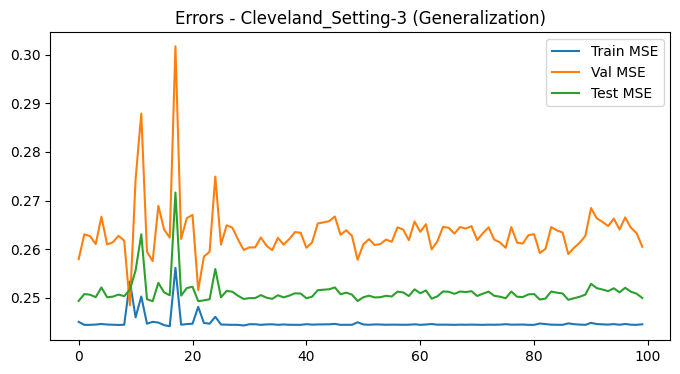

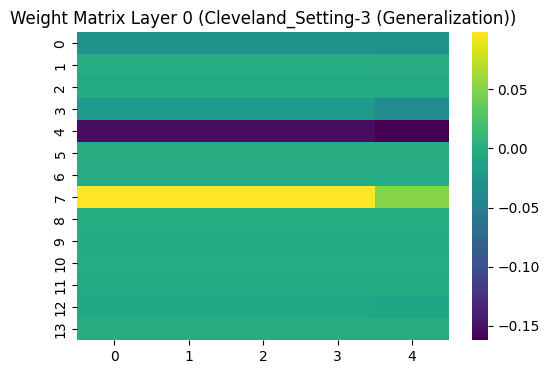

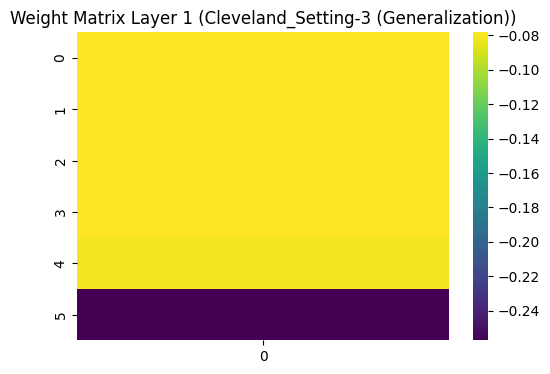

Cross-dataset results for Cleveland_Setting-3 (Generalization) model:

Running Setting-4 (LR Decay) on Cleveland Dataset...

TRAINING ON: Cleveland_Setting-4 (LR Decay)
Epoch 20 Test Confusion Matrix:
[[ 0 16]
 [ 0 15]]
Epoch 40 Test Confusion Matrix:
[[16  0]
 [15  0]]
Epoch 60 Test Confusion Matrix:
[[16  0]
 [15  0]]
Epoch 80 Test Confusion Matrix:
[[16  0]
 [15  0]]
Epoch 100 Test Confusion Matrix:
[[16  0]
 [15  0]]


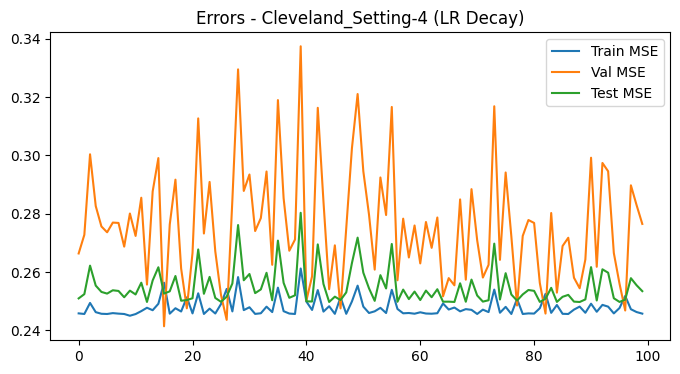

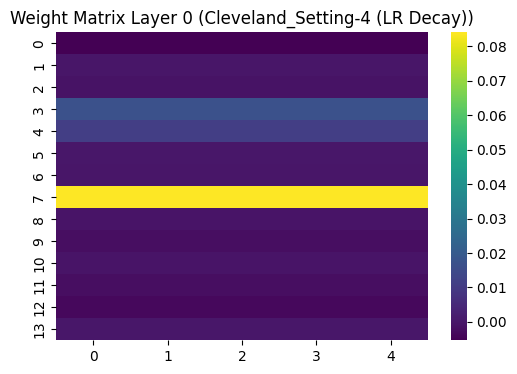

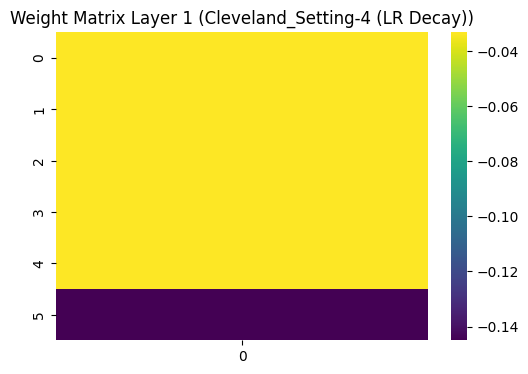

Cross-dataset results for Cleveland_Setting-4 (LR Decay) model:


In [164]:
for label, config in settings_to_run.items():

    display_name = f"Cleveland_{label}"

    print(f"\nRunning {label} on Cleveland Dataset...")


    model = run_experiment(
        display_name,
        {display_name: get_binary_data(cland)},
        config
    )
    results_summary[label] = model